## EDA - Dataset Pokémon

Análisis Exploratorio de Datos (EDA) sobre el dataset de Pokémon. El dataset contiene información de **800 Pokémon** con sus estadísticas base (HP, Ataque, Defensa, etc.), tipos y generación.


### Imports y funciones auxiliares

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Función para graficar histograma con media y desvío estándar
def plot_histograma(data, column, figsize=(7, 3), bins=15, kde=True):
    skewness = data[column].skew()
    kurtosis = data[column].kurt()
    media = data[column].mean()
    var = data[column].var()
    std = data[column].std()

    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)

    plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
    plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
    plt.axvline(media + std, color='orange', linestyle=':', label=f'+1 Std: {media+std:.1f}')
    plt.axvline(media - std, color='orange', linestyle=':', label=f'-1 Std: {media-std:.1f}')

    plt.figtext(0.72, 0.80, f'Asimetría: {skewness:.2f}', fontsize=9, color='blue')
    plt.figtext(0.72, 0.73, f'Curtosis:  {kurtosis:.2f}', fontsize=9, color='blue')
    plt.figtext(0.72, 0.66, f'Var:       {var:.1f}',      fontsize=9, color='red')
    plt.figtext(0.72, 0.59, f'Std:       {std:.1f}',      fontsize=9, color='orange')

    plt.title(f'Distribución de: {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [3]:
# Función para mostrar frecuencias de variables categóricas
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías en '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Categorías presentes: {dataframe[columna].unique()}\n")

    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)

    freq_tabla = pd.DataFrame({
        'Frecuencia absoluta': freq,
        'Frecuencia relativa (%)': freq_rel
    })
    print(f"Frecuencias de '{columna}':\n{freq_tabla}\n")

In [4]:
# Función para violin y boxplot combinados
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

### Carga del dataset

In [5]:
df = pd.read_csv('Pokemon.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


### Primera inspección

In [6]:
# Tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


In [8]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct}))

            Nulos  Porcentaje (%)
#               0            0.00
Name            0            0.00
Type 1          0            0.00
Type 2        386           48.25
Total           0            0.00
HP              0            0.00
Attack          0            0.00
Defense         0            0.00
Sp. Atk         0            0.00
Sp. Def         0            0.00
Speed           0            0.00
Generation      0            0.00
Legendary       0            0.00


In [9]:
# Filas duplicadas
print(f'Filas duplicadas: {df.duplicated().sum()}')

Filas duplicadas: 0


### Tipos de variables

Clasificación de columnas según su naturaleza:

- **Numéricas continuas / discretas:** `Total`, `HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`
- **Numéricas ordinales:** `Generation` (generación 1 a 6, con orden pero no continua)
- **Categóricas nominales:** `Type 1`, `Type 2`, `Name`
- **Booleanas:** `Legendary`
- **Identificador:** `#` 

In [11]:
# Variables numéricas
num_cols = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Variables categóricas
cat_cols = ['Type 1', 'Type 2', 'Generation', 'Legendary']

print('Variables numéricas:', num_cols)
print('Variables categóricas:', cat_cols)

Variables numéricas: ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
Variables categóricas: ['Type 1', 'Type 2', 'Generation', 'Legendary']


### Estadística descriptiva

#### Variables numéricas

In [12]:
# Estadística descriptiva de las variables numéricas
df[num_cols].describe().round(2)

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,435.10,69.26,79.00,73.84,72.82,71.90,68.28
std,119.96,25.53,32.46,31.18,32.72,27.83,29.06
min,180.00,1.00,5.00,5.00,10.00,20.00,5.00
25%,330.00,50.00,55.00,50.00,49.75,50.00,45.00
50%,450.00,65.00,75.00,70.00,65.00,70.00,65.00
75%,515.00,80.00,100.00,90.00,95.00,90.00,90.00
max,780.00,255.00,190.00,230.00,194.00,230.00,180.00


In [13]:
# Asimetría y curtosis
stats_df = pd.DataFrame({
    'Asimetría (skew)': df[num_cols].skew().round(3),
    'Curtosis (kurt)': df[num_cols].kurt().round(3)
})
print(stats_df)

         Asimetría (skew)  Curtosis (kurt)
Total               0.153           -0.507
HP                  1.568            7.232
Attack              0.552            0.170
Defense             1.156            2.726
Sp. Atk             0.745            0.298
Sp. Def             0.854            1.628
Speed               0.358           -0.236


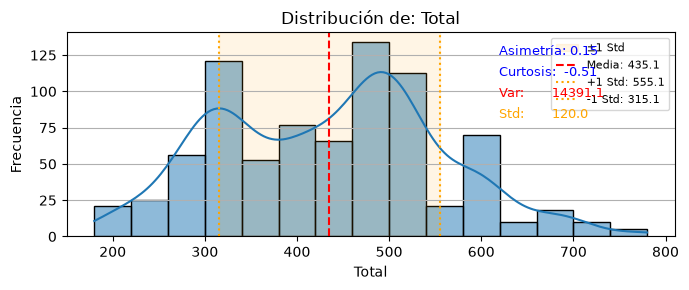

In [15]:
# Distribución de Total
plot_histograma(df, 'Total')

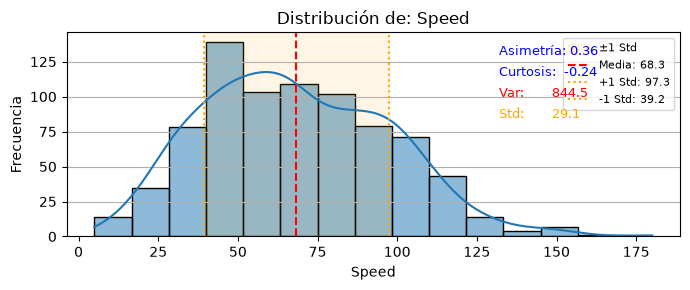

In [16]:
# Distribución de Speed
plot_histograma(df, 'Speed')

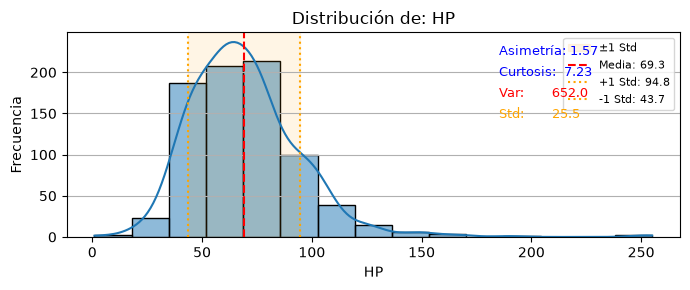

In [17]:
# Distribución de HP
plot_histograma(df, 'HP')

#### Variables categóricas

In [18]:
# Tipos primarios
print_categorias(df, 'Type 1')

Cantidad de categorías en 'Type 1': 18

Categorías presentes: <StringArray>
[   'Grass',     'Fire',    'Water',      'Bug',   'Normal',   'Poison',
 'Electric',   'Ground',    'Fairy', 'Fighting',  'Psychic',     'Rock',
    'Ghost',      'Ice',   'Dragon',     'Dark',    'Steel',   'Flying']
Length: 18, dtype: str

Frecuencias de 'Type 1':
          Frecuencia absoluta  Frecuencia relativa (%)
Type 1                                                
Water                     112                    14.00
Normal                     98                    12.25
Grass                      70                     8.75
Bug                        69                     8.62
Psychic                    57                     7.12
Fire                       52                     6.50
Electric                   44                     5.50
Rock                       44                     5.50
Ground                     32                     4.00
Ghost                      32                     4

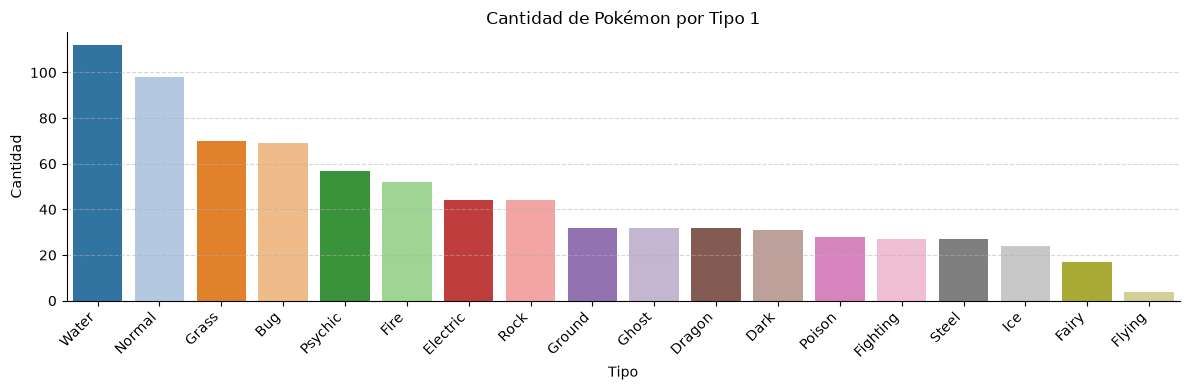

In [20]:
# Distribución de los 18 tipos primarios
plt.figure(figsize=(12, 4))
type1_counts = df['Type 1'].value_counts()
sns.barplot(x=type1_counts.index, y=type1_counts.values, palette='tab20', hue=type1_counts.index, legend=False)
plt.title('Cantidad de Pokémon por Tipo 1')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', ls='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

In [21]:
# Generación y Legendarios
print_categorias(df, 'Generation')
print('\n')
print_categorias(df, 'Legendary')

Cantidad de categorías en 'Generation': 6

Categorías presentes: [1 2 3 4 5 6]

Frecuencias de 'Generation':
            Frecuencia absoluta  Frecuencia relativa (%)
Generation                                              
1                           166                    20.75
5                           165                    20.62
3                           160                    20.00
4                           121                    15.12
2                           106                    13.25
6                            82                    10.25



Cantidad de categorías en 'Legendary': 2

Categorías presentes: [False  True]

Frecuencias de 'Legendary':
           Frecuencia absoluta  Frecuencia relativa (%)
Legendary                                              
False                      735                    91.88
True                        65                     8.12



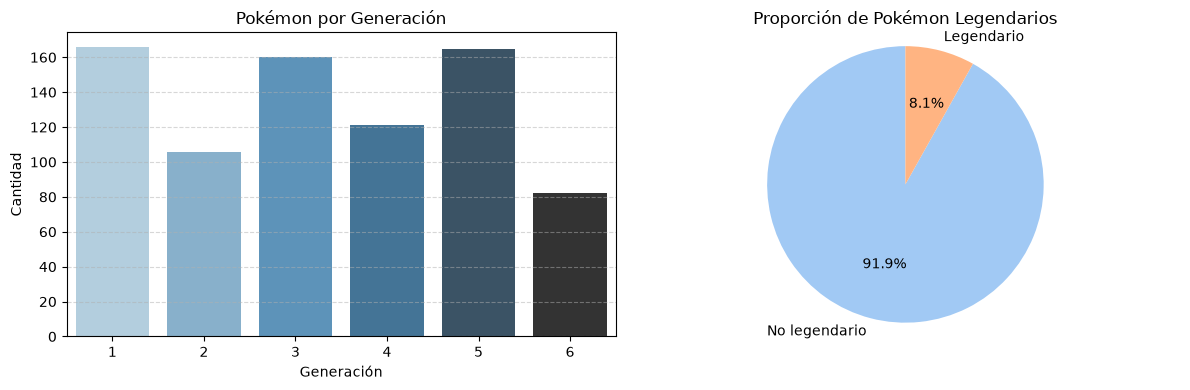

In [22]:
# Pokémon por generación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gen_counts = df['Generation'].value_counts().sort_index()
sns.barplot(x=gen_counts.index, y=gen_counts.values, palette='Blues_d', ax=axes[0], hue=gen_counts.index, legend=False)
axes[0].set_title('Pokémon por Generación')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('Cantidad')
axes[0].grid(axis='y', ls='--', alpha=0.5)

leg_counts = df['Legendary'].value_counts()
axes[1].pie(leg_counts.values, labels=['No legendario', 'Legendario'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel'))
axes[1].set_title('Proporción de Pokémon Legendarios')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

### Relación entre variables

#### Correlación entre variables numéricas

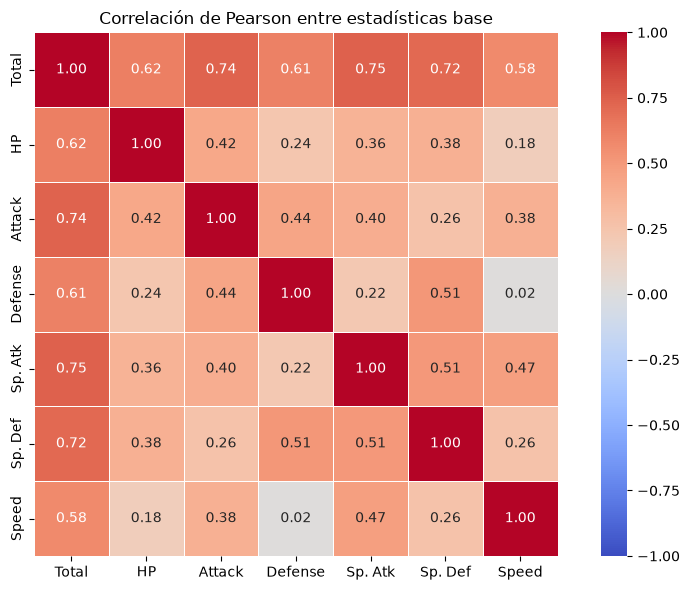

In [23]:
# Matriz de correlación de Pearson
corr_matrix = df[num_cols].corr(method='pearson')

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlación de Pearson entre estadísticas base')
plt.tight_layout()
plt.show()

#### Stats por tipo de Pokémon

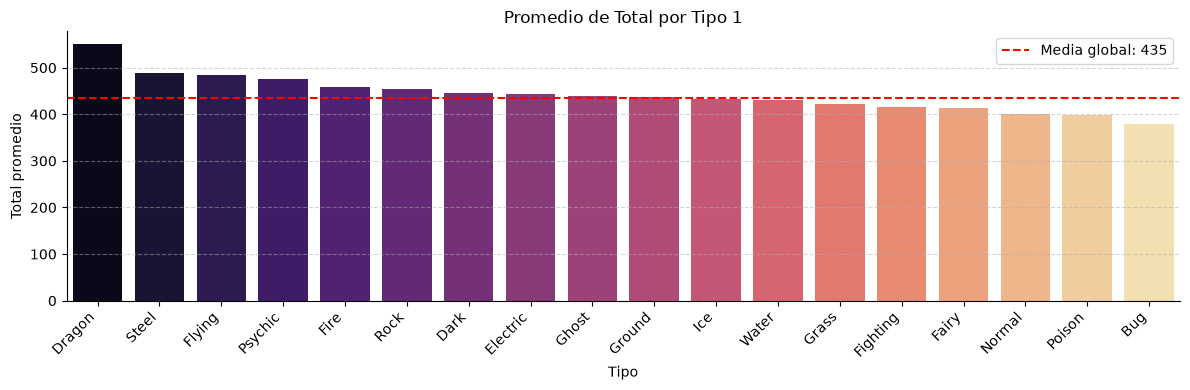

In [24]:
# Promedio de Total por tipo
tipo_stats = df.groupby('Type 1')['Total'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
sns.barplot(x=tipo_stats.index, y=tipo_stats.values, palette='magma', hue=tipo_stats.index, legend=False)
plt.axhline(df['Total'].mean(), color='red', linestyle='--', label=f'Media global: {df["Total"].mean():.0f}')
plt.title('Promedio de Total por Tipo 1')
plt.xlabel('Tipo')
plt.ylabel('Total promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', ls='--', alpha=0.5)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

#### Stats en Legendarios vs No Legendarios

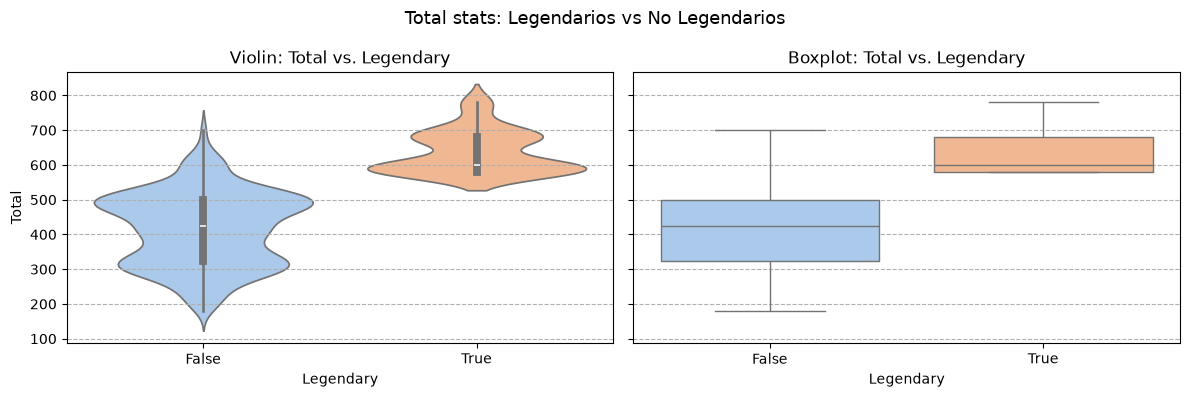

In [25]:
# Comparación de Total entre legendarios y no legendarios
plot_violin_box(df, 'Total', 'Legendary',
                title='Total stats: Legendarios vs No Legendarios')

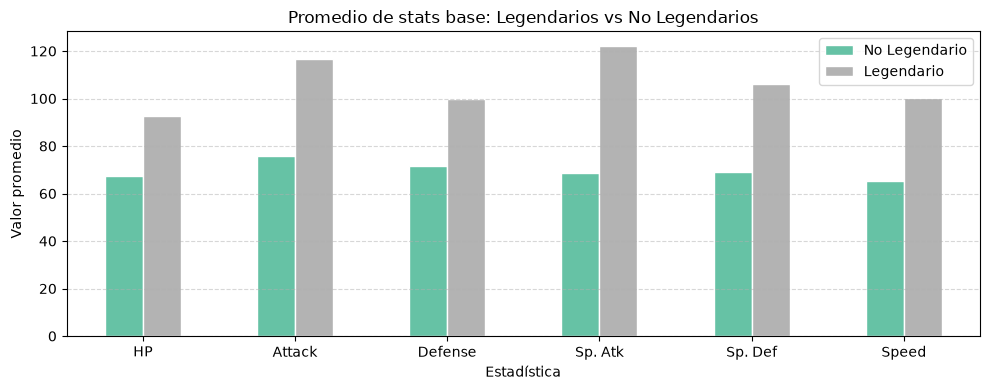

In [26]:
# Comparación de múltiples stats entre legendarios y no legendarios
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
medias = df.groupby('Legendary')[stats].mean()

medias_T = medias.T
medias_T.columns = ['No Legendario', 'Legendario']

medias_T.plot(kind='bar', figsize=(10, 4), colormap='Set2', edgecolor='white')
plt.title('Promedio de stats base: Legendarios vs No Legendarios')
plt.xlabel('Estadística')
plt.ylabel('Valor promedio')
plt.xticks(rotation=0)
plt.grid(axis='y', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### Attack vs Defense: ¿permite distinguir el tipo?

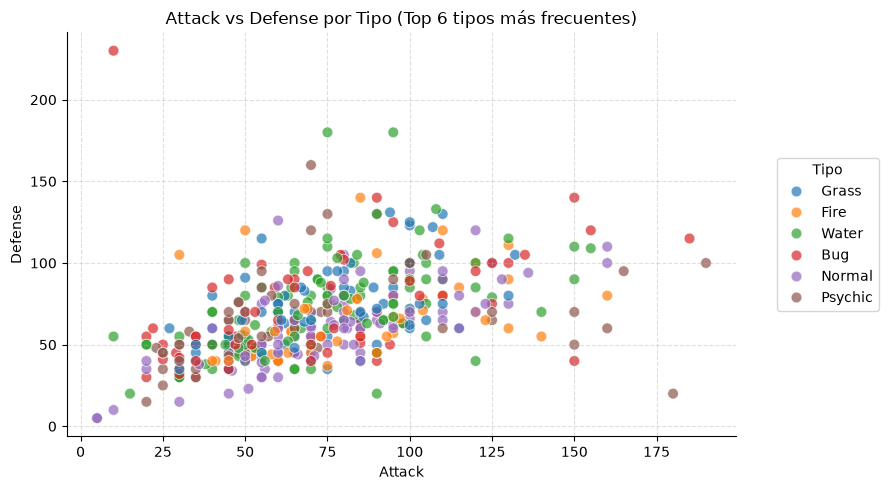

In [27]:
# Scatter plot Attack vs Defense coloreado por Type 1
# Se seleccionan los 6 tipos más frecuentes para mejor legibilidad
top_types = df['Type 1'].value_counts().head(6).index
df_top = df[df['Type 1'].isin(top_types)]

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_top, x='Attack', y='Defense',
                hue='Type 1', palette='tab10', alpha=0.7, s=60)
plt.title('Attack vs Defense por Tipo (Top 6 tipos más frecuentes)')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.grid(ls='--', alpha=0.4)
sns.despine()
plt.legend(title='Tipo', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout()
plt.show()